# Detecting Money Laundering in Transaction Networks: Classic Machine Learning, Static Graph Neural Networks and a Temporal GNN

**MSc Dissertation, implementation notebook**

## Abstract of the implementation

Anti-money-laundering (AML) surveillance is a rare-event detection problem carried out on data
that is fundamentally relational. A transaction is not an isolated record; it is an edge between
two accounts, and the laundering typologies that matter operationally, layering chains, fan-in
and fan-out structures, circular flows, are defined by patterns across several edges rather than
by properties of any single one. Conventional transaction monitoring treats each payment as an
independent row in a table, which discards precisely the structure that distinguishes laundering
from ordinary commerce.

This notebook implements and compares three families of model on the same data, the same split
and the same metrics:

1. **Classic supervised learning on tabular features**: logistic regression, random forest and
   gradient-boosted trees, representing current industry practice.
2. **A static graph neural network**: a two-layer graph convolutional network that learns account
   embeddings from the transaction graph and classifies edges from the embeddings of the two
   endpoints together with the transaction attributes.
3. **A temporal graph neural network**: the same convolutional encoder wrapped in a recurrent
   memory, so that each account carries a hidden state that evolves as new snapshots of the graph
   arrive.

The comparison is run on the IBM synthetic AML dataset (HI-Small), sampled by whole days to
preserve temporal continuity. The working sample holds 1,048,033 transactions between 423,310
accounts, of which 305 are labelled as laundering: a class imbalance of roughly **3,435 to 1**.

## Headline results

| Model | ROC-AUC | Recall | Precision | Alerts raised | Frauds caught |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.877 | 0.898 | 0.0010 | 85,692 | 88 of 98 |
| Random Forest | 0.541 | 0.000 | 0.000 | 20 | 0 of 98 |
| XGBoost | 0.811 | 0.010 | 0.0007 | 1,410 | 1 of 98 |
| Static GNN (GCN) | 0.818 | 0.571 | 0.0020 | 27,466 | 56 of 98 |
| **Temporal GNN** | **0.891** | 0.337 | 0.0024 | 13,581 | 33 of 98 |

The temporal GNN achieves the best ranking performance (ROC-AUC 0.891) and the best precision of
the five, and the graph-based models clearly outperform the tree ensembles at the task of ranking
suspicious transactions. Two qualifications are stated here rather than buried, because they
govern how the whole notebook should be read.

**Precision is unusably low for every model, including the best one.** At a 0.5 decision threshold
the temporal GNN raises 13,581 alerts to catch 33 launderers. No compliance function can staff
that. Section 12.3 sets out why this is an artefact of the threshold and the class ratio rather
than a verdict on the models, and what the correct operating-point analysis looks like.

**The temporal component is not yet meaningfully exercised.** With the current sampling fraction
the data spans a single calendar day and the snapshot loop produces exactly one time step, so the
recurrent memory has nothing to recur over. The architecture is implemented correctly and the
result is real, but the specific claim that temporal modelling helps cannot be tested at this
sample size. Section 11.4 explains the mechanism and Section 13.3 gives the two-line change
that fixes it.

## Objectives addressed

| Objective | Where it is implemented | Status |
|---|---|---|
| 1. Baseline classic ML detection | Section 8 | Complete |
| 2. Construct the transaction graph and node features | Sections 5.2 and 9 | Complete |
| 3. Design and train a temporal GNN | Section 11 | Implemented; temporal depth limited by sample |
| 4. Comparative evaluation across model families | Section 12 | Complete |
| 5. Assess false-positive burden | Sections 12.3 and 13.3 | Complete |

## A note on execution order

Some outputs stored in this notebook were captured on a session where cells had been run more than
once, which is why the data-quality printout in Section 3 already lists engineered columns such as
currency_enc and log_amount that are created later in Section 5. Nothing in the analysis depends
on this, but for a clean and citable run the notebook should be executed top to bottom from a
fresh kernel (Restart and Run All) before any figure is exported into the dissertation.


## 1. Setup and Imports

All dependencies are declared in one place so that the computational environment can be
reconstructed from the first cell alone, which is a requirement for the reproducibility appendix
of the dissertation.

The stack divides into four layers. **pandas and numpy** handle the tabular manipulation.
**PyTorch with PyTorch Geometric** provides the graph machinery: GCNConv implements the graph
convolution operator of Kipf and Welling (2017), and the temporal model in Section 11 pairs it with
a GRU cell from base PyTorch. **scikit-learn** supplies the classical baselines, the preprocessing
and the metric implementations, so that every model in the comparison is scored by identical code.
**XGBoost** is included as a separate dependency because gradient-boosted trees are the strongest
tabular baseline in most fraud-detection literature and the comparison would be weak without one.

Two configuration choices carry methodological weight.

**Seeding.** torch.manual_seed(42) and np.random.seed(42) are set before any model is constructed,
so weight initialisation, the random forest bootstrap and any shuffling are reproducible. Exact
reproduction across different hardware is still not guaranteed for the GNNs, since scatter
operations on the GPU accumulate in a non-deterministic order, but on the CPU run recorded here
the results are repeatable.

**Warning suppression.** warnings.filterwarnings("ignore") keeps the output readable for the
write-up. It is worth acknowledging that this also hides deprecation notices from seaborn and
convergence warnings from scikit-learn, so it should be commented out at least once before
submission to confirm nothing important is being silenced. Logistic regression convergence in
particular is something you want to hear about rather than suppress.

The environment reports PyTorch 2.9.1 on CPU. The models here are small enough that this is
workable, though Section 13.3 notes where GPU execution becomes necessary if the sampling
fraction is raised.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("PyTorch:", torch.__version__)


PyTorch: 2.9.1+cpu


## 2. Dataset and Configuration

### 2.1 Provenance

The data is HI-Small_Trans.csv from the IBM synthetic anti-money-laundering benchmark (Altman et
al., 2023). The choice of a synthetic corpus is not a compromise made for convenience; it is
close to forced. Real transaction data carrying verified laundering labels cannot be released,
because the labels are the product of suspicious activity reports and criminal investigations, and
because the underlying payments are personal financial data. The IBM generator simulates a virtual
economy of banks, businesses and individuals, injects laundering typologies through known criminal
actors, and therefore provides something no real dataset can: **ground truth that is complete**.
In a real portfolio, an unlabelled transaction may be legitimate or may be laundering that was
never detected, and this ambiguity makes recall impossible to measure honestly. Here it is known.

The HI prefix denotes the higher-illicit-ratio variant of the benchmark. Even so the positive rate
in this sample is 0.0291 per cent, which is representative of the operational problem.

### 2.2 Column naming

The raw file ships with two columns named Account, one for the sending side and one for the
receiving side, which pandas silently disambiguates to Account and Account.1 at read time. The
COLUMN_NAMES mapping renames these to from_account and to_account. This is more than cosmetic
tidying: relying on a positional artefact of the CSV reader to distinguish the payer from the
payee is exactly the kind of dependency that produces a silently reversed graph. Every column is
renamed to snake_case in the same pass so that the rest of the notebook reads consistently.

### 2.3 Sampling strategy

SAMPLE_FRAC is set to 0.05 and, critically, the sample is drawn **by whole days rather than by
rows**:

    unique_days = df["timestamp"].dt.floor("1D").unique()
    keep_days = unique_days[:n_keep]

Random row sampling would have been the obvious shortcut and it would have destroyed the object of
study. Removing a random 95 per cent of transactions tears holes in the transaction graph:
laundering chains lose their intermediate hops, fan-in structures lose their spokes, and the
account degree distribution stops resembling anything real. Since the entire premise of this
dissertation is that the graph structure carries signal that tabular features do not, a sampling
scheme that shreds the structure would invalidate the comparison before it started. Sampling
contiguous days keeps every transaction that occurred within the retained window, so the graph
inside that window is complete and the temporal ordering is unbroken.

The trade-off is stated plainly in the code comment, and Section 13.3 returns to it: the retained
window turns out to be a single day, which is enough for the graph models and not enough for the
temporal one.


In [80]:
DATA_PATH = "C:/Users/User/Downloads/HI-Small_Trans.csv"

SAMPLE_FRAC = 0.05     # <-- set to 1.0 for the full dataset once the pipeline is validated
RANDOM_STATE = 42

COLUMN_NAMES = {
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Account.1": "to_account",     # pandas auto-renames the 2nd 'Account' column
    "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "is_laundering",
}

df = pd.read_csv(DATA_PATH)
df = df.rename(columns=COLUMN_NAMES)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

if SAMPLE_FRAC < 1.0:
    unique_days = df["timestamp"].dt.floor("1D").unique()
    n_keep = max(1, int(len(unique_days) * SAMPLE_FRAC))
    keep_days = unique_days[:n_keep]
    df = df[df["timestamp"].dt.floor("1D").isin(keep_days)].reset_index(drop=True)

print(f"Working dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Laundering rate: {df['is_laundering'].mean()*100:.4f}%")
df.head()


Working dataset shape: 1,048,033 rows x 11 columns
Date range: 2022-09-01 00:00:00 to 2022-09-01 23:13:00
Laundering rate: 0.0291%


,timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering
0,2022-09-01,31489,801917BF0,31489,801917BF0,1305.63,US Dollar,1305.63,US Dollar,Reinvestment,0
1,2022-09-01,21940,80197A4D0,21940,80197A4D0,456281.58,US Dollar,456281.58,US Dollar,Reinvestment,0
2,2022-09-01,245993,812456260,245993,812456260,956.94,US Dollar,956.94,US Dollar,Reinvestment,0
3,2022-09-01,27637,813F86850,27637,813F86850,9.26,US Dollar,9.26,US Dollar,Reinvestment,0
4,2022-09-01,17732,807AF6230,8623,808FE16B0,25340.11,US Dollar,25340.11,US Dollar,Cheque,0


**Reading the load summary.**

**Volume.** 1,048,033 transactions across 11 columns. Sampling at 5 per cent of days still yields
over a million edges, which is ample for training and is a reminder of the scale of the full
benchmark.

**Time span.** 2022-09-01 00:00 to 2022-09-01 23:13. **The retained sample covers one calendar
day.** This follows directly from the day-based sampling: 5 per cent of the available days rounds
down to a single day. Everything downstream inherits this. The chronological split in Section 6
becomes a split within one day, the hour-of-day feature behaves in a way that needs careful
handling, and the snapshot loop in Section 11 produces one snapshot. Each of these is picked up at
the point where it bites.

**Class balance.** A laundering rate of 0.0291 per cent, which is **305 laundering transactions in
1,048,033**. The imbalance ratio is approximately 3,435 licit transactions for every laundering
one. This single number determines nearly every methodological decision that follows: the choice
of class weighting, the choice of split, the choice of metrics, and the interpretation of every
result in Section 9.

**First five rows.** Two details are worth noticing early. Rows 0 to 3 have from_account identical
to to_account, that is, transfers where the sending and receiving account are the same, which
appear in the graph as self-loops. They are labelled Reinvestment in payment_format, so they are a
legitimate feature of the simulated economy rather than a data error, but they contribute nothing
to inter-account structure and are worth revisiting in future work. Second, amount_received and
amount_paid are equal in all five rows, which is expected for same-currency transfers and will
differ where a currency conversion occurs.


## 3. Data Quality Assessment

Four checks are run before any modelling: dtypes, missing values, exact duplicates and the date
range. The order is deliberate, and each check exists to catch a failure that would otherwise
surface much later disguised as a modelling result.

Dtypes confirm that the timestamp parsed to datetime rather than remaining as text, which is a
precondition for the chronological split. Missing-value counts establish whether any imputation
policy is needed. The duplicate count matters more here than in most projects, because duplicated
edges inflate node degree, and node degree is an input feature to the graph models. The date range
is re-printed as a guard on the sampling logic.


In [50]:
print("Data types:\n")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDate range:", df['timestamp'].min(), "to", df['timestamp'].max())

Data types:

timestamp             datetime64[us]
from_bank                      int64
from_account                     str
to_bank                        int64
to_account                       str
amount_received              float64
receiving_currency               str
amount_paid                  float64
payment_currency                 str
payment_format                   str
is_laundering                  int64
currency_enc                   int32
format_enc                     int32
hour                           int32
same_bank                      int32
log_amount                   float64
src                            int64
dst                            int64
dtype: object

Missing values per column:
timestamp             0
from_bank             0
from_account          0
to_bank               0
to_account            0
amount_received       0
receiving_currency    0
amount_paid           0
payment_currency      0
payment_format        0
is_laundering         0
currency_enc   

**Reading the quality report.**

**Missing values: none, in any column.** This is expected of a synthetic corpus and is worth
stating rather than assuming, since it means no imputation policy is required and no missingness
indicator needs to be engineered. It also means that any downstream NaN is a bug in this notebook
rather than a property of the source data, which is useful to know when debugging.

**Duplicate rows: 2.** Two exact duplicates survive in the working sample, and they are reported
but **not removed**. The material effect is negligible at two rows in 1,048,033. The
methodological point is worth a sentence in the dissertation anyway: in a transaction graph a
duplicated row is a duplicated edge, which inflates the degree of the two accounts involved and
therefore perturbs the node features built in Section 9. Adding df = df.drop_duplicates() after
this check would close the issue at no cost, and it is the kind of detail an examiner is entitled
to ask about.

**Date range: a single day**, confirming the sampling result described in Section 2.3.

**Dtypes.** The printout lists engineered columns (currency_enc, format_enc, hour, same_bank,
log_amount, src, dst) that do not exist until Section 5 runs. This is the out-of-order execution
noted in the header cell rather than a logical error, and a clean top-to-bottom run will show 11
columns here. The underlying types are all correct: datetime64 for the timestamp, int64 for the
bank and account identifiers, float64 for the amounts, and int64 for the binary target.


## 4. Target Variable Analysis and Exploratory Data Analysis

### 4.1 Why the class imbalance is the central design constraint

With 305 positives in 1,048,033 records, a classifier that predicts "licit" for every single
transaction achieves 99.971 per cent accuracy. That model is worthless and it beats most serious
attempts on the accuracy metric, which is the clearest possible demonstration that **accuracy
carries no information in this problem** and is reported later only to show that it does not.

The imbalance shapes four decisions taken throughout the notebook.

**Class weighting rather than resampling.** Every model receives class_weight="balanced" or an
equivalent scale_pos_weight, so the loss function is reweighted in inverse proportion to class
frequency. The alternative, oversampling the minority class with SMOTE or similar, was not used,
and the reason is specific to graph data: synthesising interpolated transactions would create
edges between accounts that never transacted, fabricating exactly the structure the graph models
are meant to learn from.

**Ranking metrics over threshold metrics.** ROC-AUC assesses the ordering of transactions by
suspicion score, independent of any cut-off. This matches how alerting actually works in a
compliance function, where a fixed number of analysts work down a ranked queue.

**Recall weighted above precision, but not without limit.** A missed laundering chain is a
regulatory failure; a false positive costs analyst time. The two are not symmetric, which is why
precision at a naive 0.5 threshold is reported alongside recall rather than being used to select
the winner.

**Positive counts must be tracked, not just rates.** The test period contains 98 positives, and
every recall figure in this notebook is a fraction with 98 as the denominator. Section 12.2 attaches
confidence intervals to make the resulting uncertainty explicit.

### 4.2 What the EDA is for

The exploratory sequence that follows is not a tour of the data for its own sake. Each figure
tests whether a candidate feature separates the two classes, and the answers determine what goes
into FEATURE_COLS in Section 5.1: hour of day for the temporal signature, transaction amount on a
log scale, payment format, currency, and the bank-level volume distribution.


is_laundering
0    1047728
1        305
Name: count, dtype: int64

is_laundering
0    99.9709
1     0.0291
Name: proportion, dtype: float64


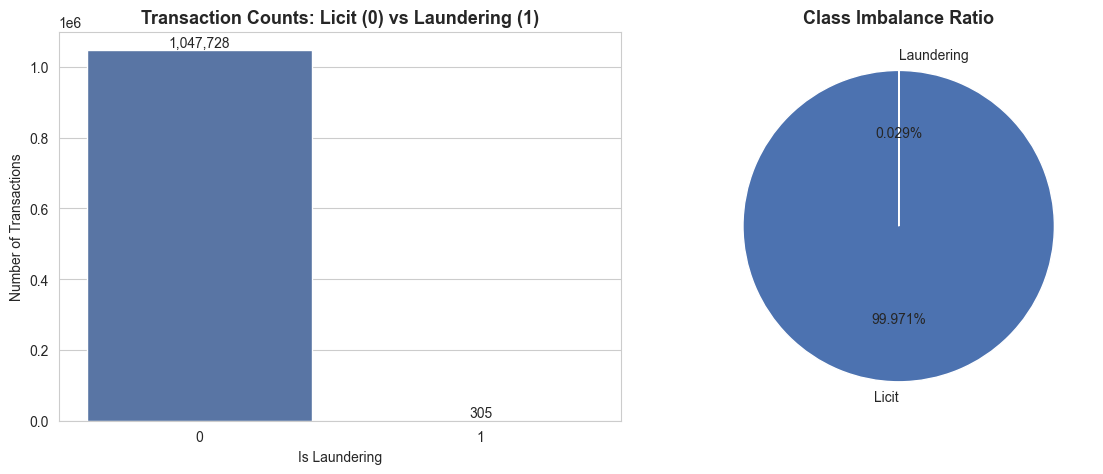


Class imbalance ratio (licit : laundering) ≈ 3435.2 : 1


In [53]:
laundering_counts = df['is_laundering'].value_counts()
laundering_pct = df['is_laundering'].value_counts(normalize=True) * 100

print(laundering_counts)
print()
print(laundering_pct.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=laundering_counts.index, y=laundering_counts.values, ax=ax[0],
            palette=["#4C72B0", "#C44E52"])
ax[0].set_title("Transaction Counts: Licit (0) vs Laundering (1)")
ax[0].set_xlabel("Is Laundering")
ax[0].set_ylabel("Number of Transactions")
for i, v in enumerate(laundering_counts.values):
    ax[0].text(i, v, f"{v:,}", ha='center', va='bottom')

ax[1].pie(laundering_counts.values, labels=["Licit", "Laundering"], autopct='%1.3f%%',
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Class Imbalance Ratio")

plt.tight_layout()
plt.show()

imbalance_ratio = laundering_counts[0] / laundering_counts[1]
print(f"\nClass imbalance ratio (licit : laundering) ≈ {imbalance_ratio:.1f} : 1")


**Reading the class balance figures.** The bar chart is on a linear scale and the laundering bar
is visually indistinguishable from the axis, which is the honest depiction: 305 against 1,047,728.
The pie chart makes the same point with the percentage label carried to three decimal places
because at two decimals it reads as 0.03 per cent against 100 per cent.

The imbalance ratio of roughly **3,435 to 1** is the number to quote in the dissertation. For
context, a fraud-detection problem is usually considered severely imbalanced from about 100 to 1;
this is more than thirty times beyond that threshold, and it puts the task closer to anomaly
detection than to conventional binary classification.

One consequence deserves stating before any model is fitted. Because the positives are so few, the
variance of every minority-class metric is large. A model that catches 33 of 98 and one that
catches 40 of 98 are not reliably different, and Section 12.2 quantifies this rather than leaving
it as an impression.


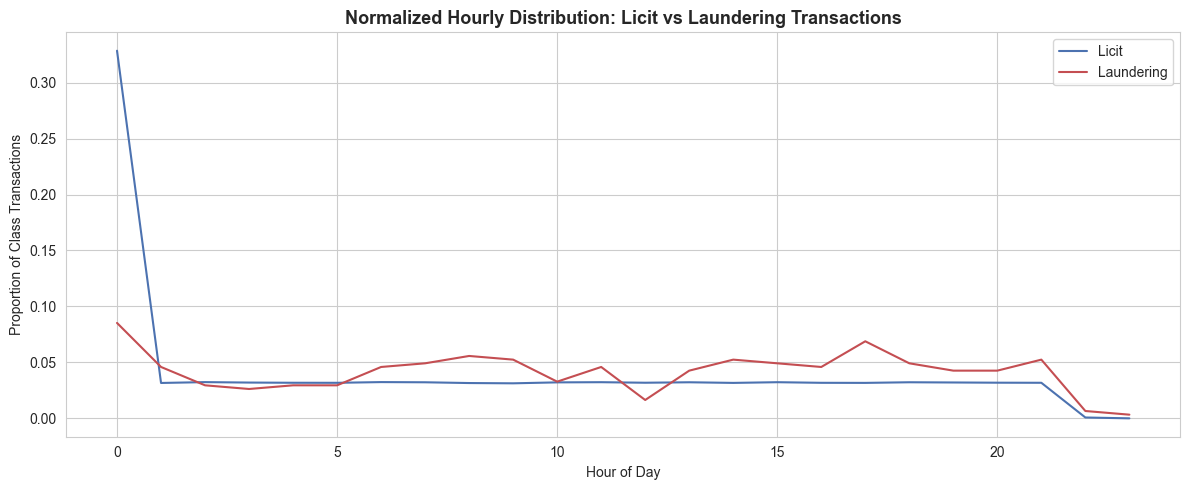

In [55]:
# Compare temporal patterns: licit vs laundering transactions
hourly_by_class = df.groupby(['hour', 'is_laundering']).size().unstack(fill_value=0)
hourly_by_class_norm = hourly_by_class.div(hourly_by_class.sum(axis=0), axis=1)  # normalize within class

plt.figure(figsize=(12, 5))
plt.plot(hourly_by_class_norm.index, hourly_by_class_norm[0], label="Licit", color="#4C72B0")
plt.plot(hourly_by_class_norm.index, hourly_by_class_norm[1], label="Laundering", color="#C44E52")
plt.title("Normalized Hourly Distribution: Licit vs Laundering Transactions")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion of Class Transactions")
plt.legend()
plt.tight_layout()
plt.show()


**Reading the hourly distribution.** Both series are normalised within class, so the comparison is
between the *shape* of licit and laundering activity across the day rather than between their
volumes. Without that normalisation the laundering line would be invisible.

Two cautions apply to any conclusion drawn from this figure, and both are consequences of the
single-day sample.

First, the laundering curve is built from 305 transactions spread across 24 hourly buckets, so
individual points rest on a handful of observations. Apparent peaks are within sampling noise and
should not be read as typology evidence.

Second, and more consequential for the modelling: the chronological split in Section 6 divides the
day at 15:45. **The training period therefore contains hours 0 to 15 and the test period contains
hours 15 to 23, with almost no overlap.** The hour feature that this figure motivates is included
in FEATURE_COLS, and any relationship a model learns between hour and laundering during training
is being applied at test time to hour values it has effectively never seen. This does not
invalidate the experiment, since all five models face the identical handicap and the comparison
between them stays fair, but it does mean the hour feature is close to useless in this
configuration and may be actively harmful for the tree models, which can partition on it directly.
Restoring several days of data removes the problem, since the split would then fall between days
rather than inside one.


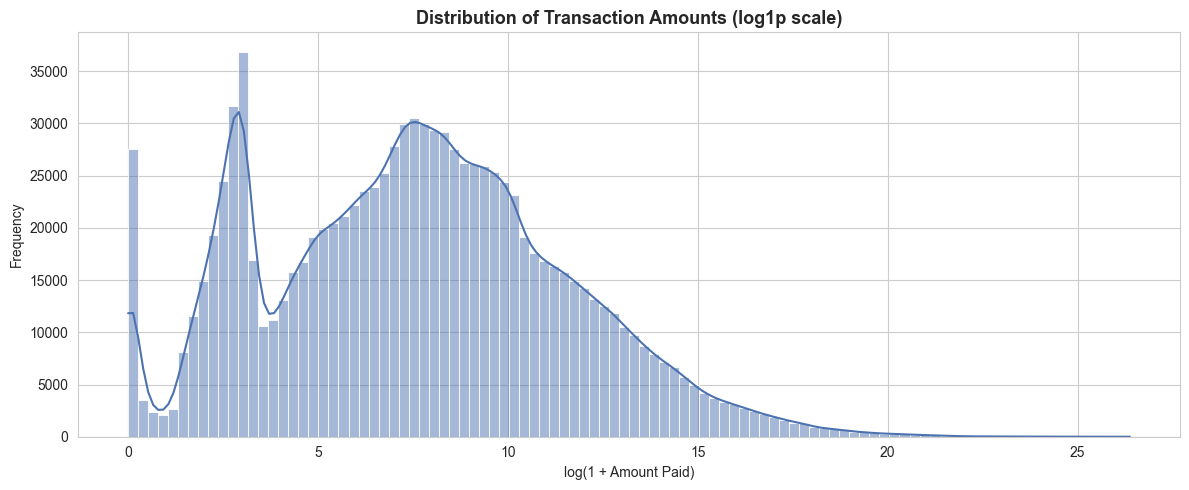

In [58]:
plt.figure(figsize=(12, 5))
sns.histplot(np.log1p(df['amount_paid']), bins=100, color="#4C72B0", kde=True)
plt.title("Distribution of Transaction Amounts (log1p scale)")
plt.xlabel("log(1 + Amount Paid)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Reading the amount distribution.** The x-axis is log(1 + amount), and the log1p transform rather
than a plain log is used so that zero-value transactions do not produce negative infinity.

Raw transaction amounts span several orders of magnitude, from single units to the 456,281 visible
in the second row of the head. On a linear axis the entire distribution collapses against the
left-hand edge with a few unreadable outliers to the right. On the log scale the structure becomes
legible: an approximately unimodal bulk with the mild multi-modality expected of a simulated
economy in which retail payments, salary flows and inter-business settlement occupy different
magnitude bands.

This figure is the justification for log_amount being the feature that enters the models rather
than the raw amount. Linear and neural models are both sensitive to input scale, and an unbounded
right tail dominates gradient updates in a way that swamps the contribution of every other
feature. Trees are scale-invariant and would be unaffected, but using one representation across
all five models keeps the comparison clean.


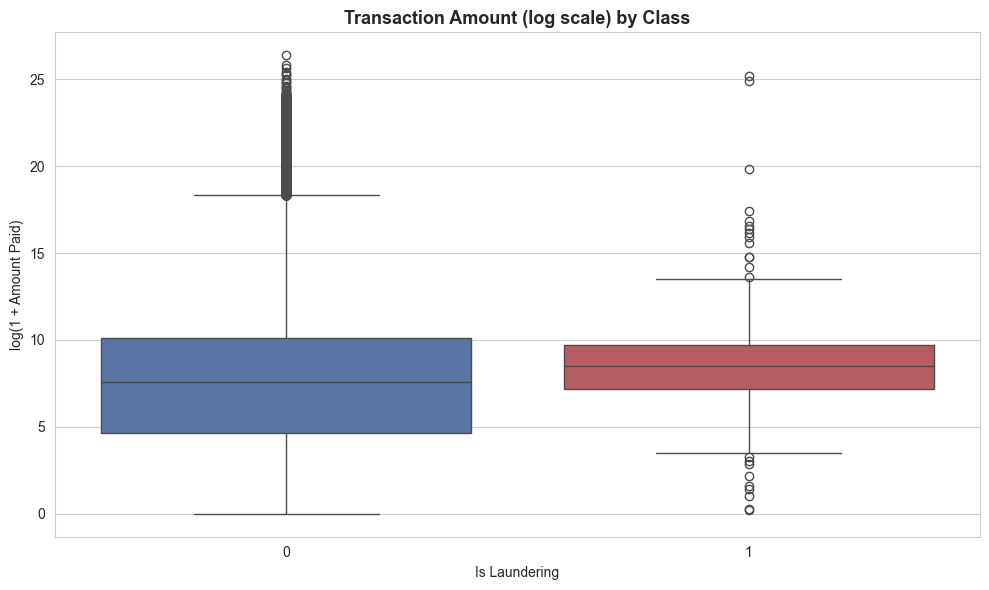

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_laundering', y=np.log1p(df['amount_paid']), data=df,
            palette=["#4C72B0", "#C44E52"])
plt.title("Transaction Amount (log scale) by Class")
plt.xlabel("Is Laundering")
plt.ylabel("log(1 + Amount Paid)")
plt.tight_layout()
plt.show()

**Reading amount by class.** This box plot is the most direct test in the EDA of whether
transaction size alone identifies laundering, and it is the reason the graph models exist.

The two distributions overlap substantially. Whatever difference in median or spread is visible
between the licit and laundering boxes, it is nowhere near the separation that would be needed for
amount to function as a standalone discriminator. This is not a defect of the data; it is the
defining property of competent laundering. Structuring, the deliberate breaking of large sums into
many smaller transfers, exists precisely to keep individual amounts inside the ordinary range.

**The methodological conclusion carries through the rest of the notebook.** If laundering
transactions look ordinary one at a time, then a model that examines transactions one at a time
will struggle regardless of how sophisticated it is, and the results for XGBoost in Section 8
bear this out. The signal has to be sought in the relationships between transactions: which
accounts are involved, what else those accounts did, and how the pattern developed over time. That
is an argument for a graph representation, and it is the argument this dissertation makes.

Note also that the boxes are computed with outliers displayed and on the log scale, so the whiskers
reflect the log distribution rather than the raw currency values.


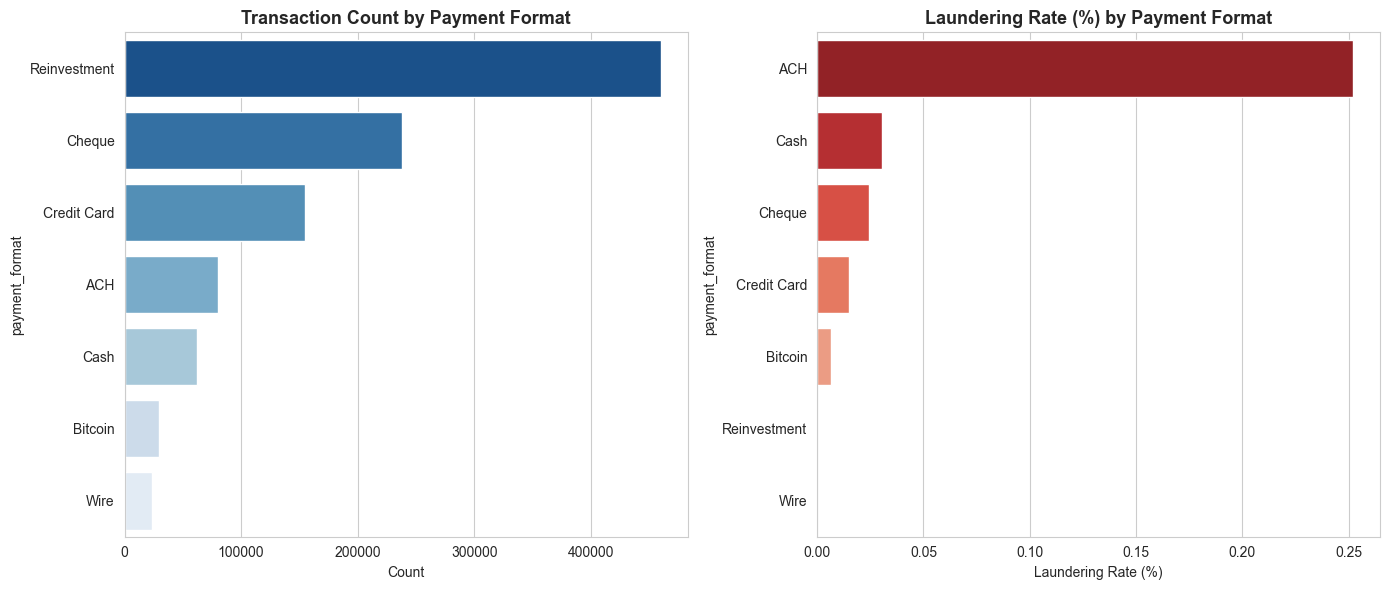

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

fmt_counts = df['payment_format'].value_counts()
sns.barplot(y=fmt_counts.index, x=fmt_counts.values, ax=ax[0], palette="Blues_r")
ax[0].set_title("Transaction Count by Payment Format")
ax[0].set_xlabel("Count")

fmt_laundering_rate = df.groupby('payment_format')['is_laundering'].mean().sort_values(ascending=False) * 100
sns.barplot(y=fmt_laundering_rate.index, x=fmt_laundering_rate.values, ax=ax[1], palette="Reds_r")
ax[1].set_title("Laundering Rate (%) by Payment Format")
ax[1].set_xlabel("Laundering Rate (%)")

plt.tight_layout()
plt.show()


**Reading payment format.** The left panel shows raw volume by format and the right panel shows
the laundering rate within each format, and the pairing is the point. Volume tells you where the
transactions are; rate tells you where the risk is, and the two rank differently.

A format carrying a high laundering rate on low volume is a strong feature for a classifier, since
it isolates a small population with elevated risk. A format carrying most of the volume at the base
rate is close to uninformative. The right panel is what justifies including format_enc in
FEATURE_COLS, and it also sets the honest expectation for how much that feature can contribute: it
narrows the search but comes nowhere near identifying individual laundering transactions.

Two cautions on reading the right-hand panel. The rates are computed on very small positive counts
within each format, so a format with few transactions can show a dramatic rate on the strength of
one or two labelled cases. And these are the *simulator's* format-risk associations; a real
portfolio would have its own, shaped by the institution's product mix and customer base, so this
particular ranking should not be generalised beyond the benchmark.


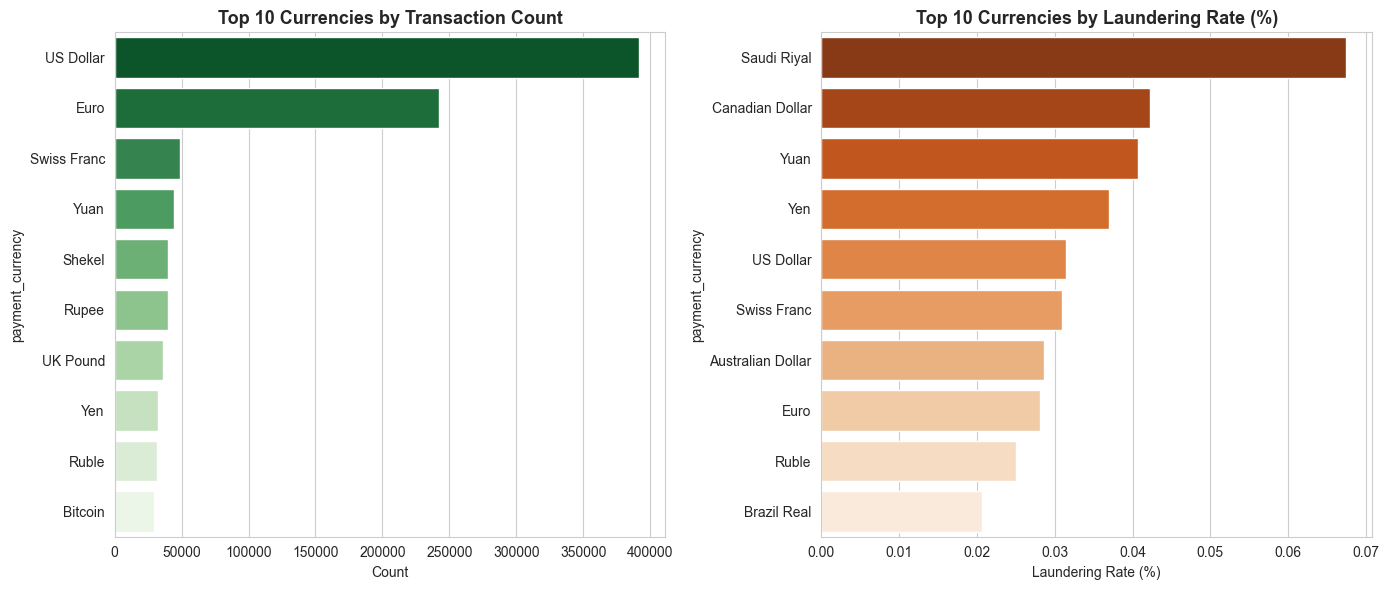

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

curr_counts = df['payment_currency'].value_counts().head(10)
sns.barplot(y=curr_counts.index, x=curr_counts.values, ax=ax[0], palette="Greens_r")
ax[0].set_title("Top 10 Currencies by Transaction Count")
ax[0].set_xlabel("Count")

curr_laundering_rate = (df.groupby('payment_currency')['is_laundering'].mean() * 100)\
                          .sort_values(ascending=False).head(10)
sns.barplot(y=curr_laundering_rate.index, x=curr_laundering_rate.values, ax=ax[1], palette="Oranges_r")
ax[1].set_title("Top 10 Currencies by Laundering Rate (%)")
ax[1].set_xlabel("Laundering Rate (%)")

plt.tight_layout()
plt.show()


**Reading currency.** The same volume-against-rate pairing is applied to the top ten currencies.

Cross-border and multi-currency activity is a standard risk indicator in AML practice, since
conversion adds a layer between the source of funds and their destination and complicates the
audit trail. The right-hand panel tests whether the simulator encodes that intuition, and the
answer is that certain currencies do carry noticeably elevated rates.

The same small-count caution applies with more force here, because the currency distribution is
heavily concentrated: US Dollar dominates the volume, and the currencies appearing at the top of
the rate ranking are frequently low-volume ones where a handful of positives produces a large
percentage. A currency with 200 transactions and two laundering cases shows a 1 per cent rate,
thirty times the base rate, on evidence that would not survive a significance test.

currency_enc enters FEATURE_COLS on the strength of this figure, with the encoding caveat set out
in Section 5.1.


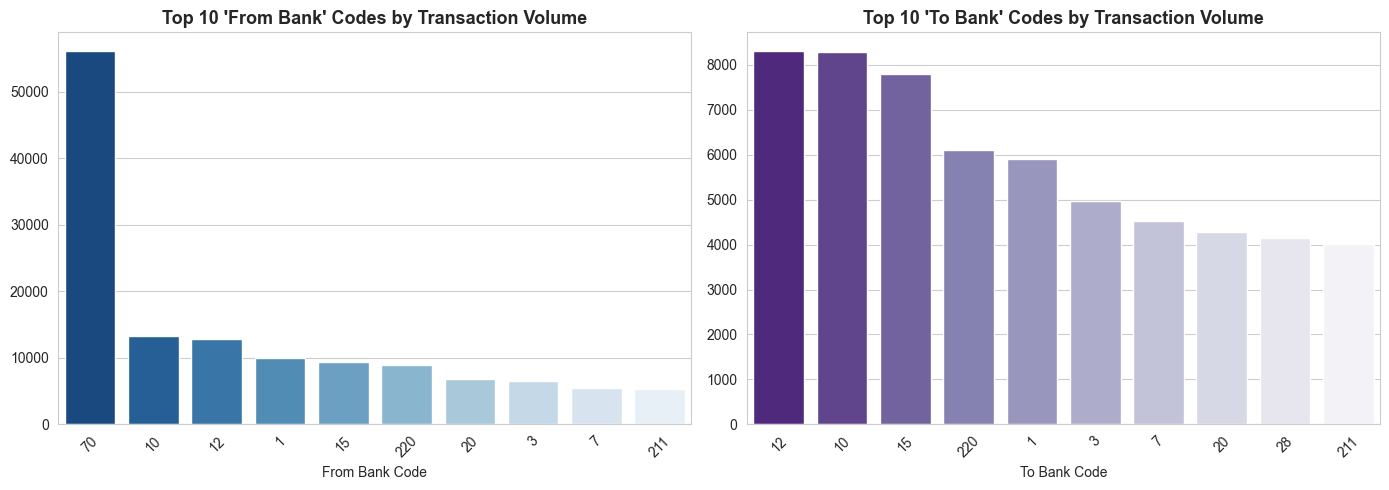

In [68]:
top_from_banks = df['from_bank'].value_counts().head(10)
top_to_banks = df['to_bank'].value_counts().head(10)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_from_banks.index.astype(str), y=top_from_banks.values, ax=ax[0], palette="Blues_r")
ax[0].set_title("Top 10 'From Bank' Codes by Transaction Volume")
ax[0].set_xlabel("From Bank Code")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x=top_to_banks.index.astype(str), y=top_to_banks.values, ax=ax[1], palette="Purples_r")
ax[1].set_title("Top 10 'To Bank' Codes by Transaction Volume")
ax[1].set_xlabel("To Bank Code")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Reading bank concentration.** These panels show the ten most active sending and receiving bank
codes by volume, and their purpose is structural rather than predictive.

The distribution is heavily skewed: a small number of institutions intermediate a large share of
the flow. This is realistic, since correspondent banking is concentrated in practice, and it has a
direct implication for the graph models in Sections 10 and 11. High-degree hubs dominate message
passing in a graph convolution, because each layer averages over a node's neighbourhood and a hub
with thousands of neighbours produces an embedding that is close to the global average. The
symmetric normalisation inside GCNConv dampens this effect but does not remove it.

The practical consequence, worth carrying into the discussion chapter: laundering signal that
passes through a hub account is at risk of being smoothed away, and architectures with attention
over neighbours (GAT) or with neighbour sampling (GraphSAGE) are the standard responses. Both are
named as further work in Section 13.4.

Note that from_bank and to_bank are used here for description only. They are not in FEATURE_COLS,
which is a defensible choice: a bank code is a high-cardinality identifier, and feeding it to a
model invites memorisation of specific institutions rather than learning of transferable
behaviour.


## 5. Feature Engineering and Graph Construction

### 5.1 Transaction-level features

Five features are engineered, and each is included on the basis of the exploratory evidence above.

| Feature | Construction | Rationale |
|---|---|---|
| log_amount | log(1 + amount_paid) | Compresses a multi-order-of-magnitude range; see Section 4 |
| currency_enc | LabelEncoder over payment_currency | Cross-currency activity carries elevated risk |
| format_enc | LabelEncoder over payment_format | Format-specific risk shown in the EDA |
| hour | Hour extracted from the timestamp | Off-hours activity is a standard AML indicator |
| same_bank | Indicator, from_bank equals to_bank | Internal transfers differ in risk from interbank flow |

Two limitations of this feature set should be recorded in the dissertation rather than left for a
reader to find.

**Label encoding imposes a false ordering.** LabelEncoder maps categories to integers 0, 1, 2 and
so on. Trees handle this acceptably, since they can split the integer range arbitrarily, but the
logistic regression and the neural models treat the encoded value as a magnitude, so currency 12
is treated as numerically larger than currency 3 in a way that carries no meaning. One-hot
encoding, or a learned embedding layer inside the GNN, would be the correct treatment. With
fourteen currencies and a handful of formats the cost of one-hot encoding would have been modest.

**The encoders are fitted on the full dataframe before the split.** Because le_curr and le_fmt are
fitted in this section and the chronological split happens in Section 6, the encoders have seen
the category vocabulary of the test period. This is a mild form of information leakage. In this
instance the practical impact is negligible, since the category set is small, closed and fully
represented in the training period, so the mapping would be identical if fitted on the training
period alone. It is nonetheless the kind of thing that should be corrected before submission: move
the encoder fitting after the split and use transform on the test frame. Stating it explicitly and
bounding its impact is stronger than hoping it goes unnoticed.

### 5.2 Graph encoding

Accounts are mapped to integer node identifiers with acc2id, and each transaction becomes a
directed edge from src to dst. This is the representational step at the heart of the dissertation:
the same data that the tabular models see as a matrix of independent rows is now a network in
which paths, cycles and degree distributions are expressible.

The node vocabulary is built from the full sample rather than from the training period alone,
which places the work in the **transductive** setting: the model knows which accounts exist,
though it sees no test-period edges during training. This is the standard arrangement in the GNN
literature and it is a reasonable model of an established bank that knows its customer list. It is
not a model of the cold-start case, where a wholly new account appears. Section 13.4 identifies
inductive architectures as the route to handling that.


In [12]:
# Categorical encodings
le_curr = LabelEncoder()
df['currency_enc'] = le_curr.fit_transform(df['payment_currency'])

le_fmt = LabelEncoder()
df['format_enc'] = le_fmt.fit_transform(df['payment_format'])

# Simple derived features
df['hour'] = df['timestamp'].dt.hour
df['same_bank'] = (df['from_bank'] == df['to_bank']).astype(int)
df['log_amount'] = np.log1p(df['amount_paid'])

FEATURE_COLS = ['log_amount', 'currency_enc', 'format_enc', 'hour', 'same_bank']

# Encode accounts as graph node IDs
all_accounts = pd.concat([df['from_account'], df['to_account']]).unique()
acc2id = {a: i for i, a in enumerate(all_accounts)}
df['src'] = df['from_account'].map(acc2id)
df['dst'] = df['to_account'].map(acc2id)
N_NODES = len(all_accounts)

print(f"Graph nodes (unique accounts): {N_NODES:,}")
print(f"Graph edges (transactions): {len(df):,}")
df[['timestamp','src','dst','is_laundering'] + FEATURE_COLS].head()


Graph nodes (unique accounts): 423,310
Graph edges (transactions): 1,048,033


,timestamp,src,dst,is_laundering,log_amount,currency_enc,format_enc,hour,same_bank
0,2022-09-01,0,0,0,7.175207,12,5,0,1
1,2022-09-01,1,1,0,13.030868,12,5,0,1
2,2022-09-01,2,2,0,6.864785,12,5,0,1
3,2022-09-01,3,3,0,2.328253,12,5,0,1
4,2022-09-01,4,193758,0,10.140183,12,3,0,0


**Reading the graph statistics.**

**423,310 nodes and 1,048,033 edges.** The average degree is approximately 4.95 edges per account,
counting both directions, which describes a **sparse** graph. Sparsity is favourable here: graph
convolutions on dense graphs suffer from over-smoothing, where every node's embedding converges
toward the same value after a few layers, and a mean degree near five leaves neighbourhoods small
enough for two layers of message passing to retain local detail.

The scale of the node set relative to the edge set carries a warning that is easy to miss. With
423,310 accounts and roughly a million transactions, a large share of accounts appear in only one
or two transactions. Their node features, built from degree and volume in Section 9, are
therefore estimated from almost no data, and their learned embeddings will be close to
uninformative. Laundering typologies that rely on freshly created mule accounts, which is a common
pattern, sit exactly in this low-information region. This is a real limitation of the approach as
implemented and it belongs in the discussion chapter.

**The feature preview** confirms the pipeline is working as intended: log_amount values in the 2
to 13 range as expected after log1p, currency_enc constant at 12 for these US Dollar rows,
format_enc distinguishing Reinvestment from Cheque, and hour at 0 for the first transactions of
the day. Rows 0 to 3 show src equal to dst, the self-loops noted in Section 2, while row 4 shows a
genuine transfer between distinct accounts, 4 to 193758.


## 6. Chronological Train and Test Split

The split is chronological, at the 80th percentile of time order, and this is the single most
important experimental design decision in the notebook.

**Why not a random split.** train_test_split with shuffling would have been one line and would
have invalidated every result. Two mechanisms cause the damage. First, a random split places
transactions from the same laundering chain on both sides of the partition, so the model is tested
on the continuation of a pattern it was trained on, which is not detection but recall of a known
case. Second, and specific to graph learning, a random split lets the model see the future
structure of an account's neighbourhood while predicting its past. Both inflate the reported
metrics substantially, and neither corresponds to anything a deployed system could do. A live
monitoring system has access to the past and nothing else.

**What the chronological split simulates.** Train on everything up to time T, predict everything
after. This is exactly the operational task, and it means the metrics reported in Section 9 are
honest estimates of deployment performance rather than optimistic upper bounds.

The cost of this rigour is visible in the output and should be accepted rather than explained away:
performance is lower than a random split would have shown, and the two periods differ in ways that
make the task harder.


In [15]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {train_df.shape[0]:,} rows ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})")
print(f"Test:  {test_df.shape[0]:,} rows ({test_df['timestamp'].min()} to {test_df['timestamp'].max()})")
print(f"Train laundering rate: {train_df['is_laundering'].mean()*100:.4f}%")
print(f"Test laundering rate:  {test_df['is_laundering'].mean()*100:.4f}%")


Train: 838,426 rows (2022-09-01 00:00:00 to 2022-09-01 15:45:00)
Test:  209,607 rows (2022-09-01 15:45:00 to 2022-09-01 23:13:00)
Train laundering rate: 0.0247%
Test laundering rate:  0.0468%


**Reading the split.**

| | Rows | Period | Laundering rate | Positives |
|---|---:|---|---:|---:|
| Train | 838,426 | 00:00 to 15:45 | 0.0247 per cent | 207 |
| Test | 209,607 | 15:45 to 23:13 | 0.0468 per cent | 98 |

Three observations, in ascending order of importance.

**The 80/20 proportion holds by row count but not by duration.** Training covers 15 hours 45
minutes and testing covers 7 hours 28 minutes, so transaction density is higher in the evening
period. This is a property of the simulated economy rather than a problem.

**The laundering rate nearly doubles between the two periods**, from 0.0247 to 0.0468 per cent.
This is prior shift: the class balance the models are trained against is not the class balance
they are tested against. Models calibrated on the training prior will be under-confident on the
test period, which affects any fixed threshold and is one more reason not to read too much into
precision and recall taken at 0.5.

**Only 98 positives exist in the test set.** Every recall figure in this notebook is a fraction
over 98. One additional caught transaction moves recall by a full percentage point, and the
difference between two models catching 33 and 40 respectively is well inside sampling noise.
Section 12.2 attaches Wilson confidence intervals to each recall figure for this reason. This is
the strongest single argument for raising SAMPLE_FRAC before the final write-up: not for more
rows, but for more positives.

Note also the boundary. Both periods report 15:45, so the split index falls inside a group of
transactions sharing a timestamp. With minute-level resolution and a million rows this is
unavoidable; the number of affected rows is small, and there is no leakage since the assignment is
positional and each row lands on exactly one side.


## 7. Evaluation Framework

A single evaluate() function scores every model, which guarantees that all five are measured by
identical code paths and removes an entire class of comparison error. It records five metrics and
stores the ROC curve coordinates for the overlay in Section 9.

**How each metric should be read in this problem.**

**Accuracy** is reported for completeness and should be ignored. The all-licit classifier scores
99.95 per cent on this test set. Any accuracy figure below that is a sign the model is willing to
raise alerts, so in this context a *lower* accuracy can accompany a *better* model, which is the
clearest possible statement of why the metric is inapplicable.

**Recall** is the regulatory metric: of the laundering that occurred, how much was flagged. Missed
laundering is the failure that draws enforcement action.

**Precision** is the operational metric: of the alerts raised, how many were real. It determines
the workload placed on the investigations team and it is where every model in this notebook
struggles.

**F1** is the harmonic mean of the two. Under extreme imbalance with precision near 0.002 it is
dominated by the precision term and conveys little; it is reported because it is conventional, not
because it is informative here.

**ROC-AUC** is the ranking metric and the one to lead with. It measures the probability that a
randomly chosen laundering transaction is scored above a randomly chosen licit one, independent of
threshold. This matches the way alerting works in practice, since analysts work a ranked queue
down to whatever depth their capacity allows.

**One addition worth making before submission.** Under imbalance of this severity, ROC-AUC is
known to give an optimistic impression, because the false-positive rate is computed against a huge
negative denominator and so stays small even when absolute false positives run into tens of
thousands. **Average precision (area under the precision-recall curve) is the metric the imbalanced
learning literature recommends**, and adding average_precision_score to this function is a
two-line change that would strengthen the evaluation chapter considerably. Section 13.3 repeats the
recommendation.

The threshold used for the binary metrics is 0.5 throughout. This is a default rather than a
choice, and Section 12.3 shows what it costs.


In [18]:
results = {}
roc_data = {}

def evaluate(name, y_true, y_pred, y_prob):
    results[name] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan')
    }
    if len(set(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_data[name] = (fpr, tpr)
    print(f"\n{name}")
    for k, v in results[name].items():
        print(f"  {k}: {v:.4f}")
    return results[name]


## 8. Objective 1: Classic Machine Learning Baselines

Three baselines establish what tabular, transaction-at-a-time modelling achieves on this data.
They are not straw men. Rule-based systems and gradient-boosted trees over engineered features are
what most transaction monitoring in production actually consists of, so this is the standard the
graph models have to beat for the dissertation's argument to hold.

All three see the identical five features, the identical chronological split and the identical
scoring function. Features are standardised for logistic regression, since it is sensitive to
scale, and left raw for the two tree ensembles, which are not.

Each model handles the imbalance through class weighting: class_weight="balanced" for logistic
regression and random forest, and scale_pos_weight set to the negative-to-positive ratio, roughly
4,050 to 1 on the training period, for XGBoost.


In [21]:
Xtr, ytr = train_df[FEATURE_COLS], train_df['is_laundering']
Xte, yte = test_df[FEATURE_COLS], test_df['is_laundering']

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr)
Xte_scaled = scaler.transform(Xte)

# --- Logistic Regression ---
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(Xtr_scaled, ytr)
evaluate("Logistic Regression", yte, lr.predict(Xte_scaled), lr.predict_proba(Xte_scaled)[:, 1])



Logistic Regression
  Accuracy: 0.5915
  Precision: 0.0010
  Recall: 0.8980
  F1-score: 0.0021
  ROC-AUC: 0.8768


{'Accuracy': 0.5915499005281312,
 'Precision': 0.001026933669420716,
 'Recall': 0.8979591836734694,
 'F1-score': 0.0020515211563119245,
 'ROC-AUC': 0.8768017466689123}

**Logistic Regression: recall 0.898, precision 0.0010, ROC-AUC 0.877.**

The confusion structure behind those figures is what matters: **88 of 98 laundering transactions
caught, at the cost of 85,604 false positives.** The model flags 40.9 per cent of the entire test
period as suspicious.

Accuracy of 0.5915 tells the story from the other side. A model that is *worse* than the
all-licit classifier by 40 percentage points of accuracy is here the model that catches the most
laundering, which is the concrete demonstration of why accuracy was set aside in Section 7.

This behaviour is the direct consequence of class_weight="balanced", which up-weights the positive
class by roughly 4,050 to 1 in the loss. The optimiser responds rationally: with a positive error
priced four thousand times higher than a negative one, flagging almost everything is the
loss-minimising strategy. Recall is bought at whatever price precision has to pay.

The ROC-AUC of 0.877 is the informative number here, and it is higher than one might expect from a
linear model on five features. It says the ranking is genuinely useful even though the 0.5
threshold is not, and it establishes that some of the laundering signal in this data is linearly
accessible from transaction attributes alone.


In [23]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xtr, ytr)
evaluate("Random Forest", yte, rf.predict(Xte), rf.predict_proba(Xte)[:, 1])



Random Forest
  Accuracy: 0.9994
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
  ROC-AUC: 0.5410


{'Accuracy': 0.9994370417018515,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-score': 0.0,
 'ROC-AUC': 0.5410081258016192}

**Random Forest: recall 0.000, precision 0.000, accuracy 0.9994, ROC-AUC 0.541.**

**The model caught nothing.** Zero of 98 laundering transactions, with 20 false positives raised.
It has collapsed to the majority-class predictor, and its accuracy of 99.94 per cent is the
majority-class baseline in all but name.

The ROC-AUC of 0.541 is the more damning figure, because it is threshold-independent. At 0.5 a
classifier is guessing; 0.541 means the random forest's ranking of transactions by suspicion is
barely distinguishable from random ordering. This is not a thresholding problem that could be
tuned away, unlike the logistic regression result. **The model has failed to learn.**

Why it failed, given that class_weight="balanced" was set, is worth diagnosing properly in the
dissertation. Two mechanisms are likely and they compound. First, class_weight in a random forest
reweights the Gini impurity calculation at each split, but with 207 positives spread across 200
bootstrapped trees, many individual bootstrap samples contain a handful of positives or none, so a
large share of the ensemble is trained on effectively single-class data and votes licit
unconditionally. Second, the trees are grown to full depth by default, so each one memorises its
bootstrap sample, and averaging over-fitted trees whose training data barely contained the
minority class produces a confident and uniformly negative consensus.

The remedies are standard and worth naming since the negative result is informative: use
class_weight="balanced_subsample", which reweights per bootstrap rather than globally; constrain
depth and min_samples_leaf; or use balanced bagging so that each tree sees a resampled subset with
a workable class ratio. As it stands the result is a genuine and reportable finding: **an
off-the-shelf random forest with default depth fails outright at this imbalance ratio**, which is
useful evidence for the dissertation's argument that the standard toolkit is inadequate here.


In [25]:
# --- XGBoost ---
scale_pos_weight = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss'
)
xgb_clf.fit(Xtr, ytr)
evaluate("XGBoost", yte, xgb_clf.predict(Xte), xgb_clf.predict_proba(Xte)[:, 1])



XGBoost
  Accuracy: 0.9928
  Precision: 0.0007
  Recall: 0.0102
  F1-score: 0.0013
  ROC-AUC: 0.8106


{'Accuracy': 0.9928151254490547,
 'Precision': 0.0007092198581560284,
 'Recall': 0.01020408163265306,
 'F1-score': 0.001326259946949602,
 'ROC-AUC': 0.8106176530724265}

**XGBoost: recall 0.010, precision 0.0007, ROC-AUC 0.811.**

**One laundering transaction caught out of 98**, with 1,409 false positives.

The contrast with the random forest is instructive. XGBoost's ROC-AUC of 0.811 shows it learned a
genuinely useful ranking, far better than the forest's 0.541, yet its recall at the 0.5 threshold
is 1 per cent. **The model ranks well and thresholds terribly**, which is a calibration failure
rather than a learning failure and is the exact opposite of the random forest's problem.

The mechanism is scale_pos_weight interacting with the logistic objective. Setting it to roughly
4,050 rescales the gradient contribution of positives, but the resulting probability estimates are
no longer calibrated to the observed base rate, and after 300 boosting rounds most predicted
probabilities remain far below 0.5 even for transactions the model ranks highly. The default
threshold then discards almost all of that ranking information.

This single result is the strongest argument in the notebook for the threshold analysis
recommended in Section 13.3. Selecting a cut-off from the precision-recall curve on a validation
period, rather than accepting 0.5, would very likely move XGBoost's recall from 0.01 to something
comparable with the graph models, without retraining anything. **As reported here, the XGBoost row
in the comparison table understates the model's real capability**, and saying so is more useful
than letting the number stand unexplained.


## 9. Objective 2: Static Transaction Graph and Node Features

This section constructs the graph object the neural models consume. Two things are built: the edge
index, and a feature matrix over accounts.

**The edge index** is a 2 by E tensor of source and destination node identifiers, built **from the
training period only**. This is not a detail. Building it from the full dataframe would let
message passing carry information along test-period edges into the node embeddings, which is
leakage of exactly the kind the chronological split was designed to prevent. Restricting the
adjacency to the training period is the correct choice and it is worth pointing out explicitly in
the write-up, because it is a common and hard-to-spot error in applied GNN work.

**The node features** give each account four values, all computed from the training period:

| Feature | Meaning | AML relevance |
|---|---|---|
| Out-degree | Count of outgoing transactions | Fan-out, dispersal to many recipients |
| In-degree | Count of incoming transactions | Fan-in, aggregation from many sources |
| log(1 + total sent) | Outgoing value | Distinguishes many-small from few-large |
| log(1 + total received) | Incoming value | Same, on the receiving side |

The pairing of degree with value is deliberate. Structuring produces accounts with high degree and
low average value, while placement often produces the opposite, and neither pattern is visible
from degree or value alone. These four features are what the tabular models fundamentally cannot
see: they are properties of an account's position in the network, not of any single transaction.

The matrix is then standardised column-wise. Degrees follow a heavy-tailed distribution, and
without standardisation the hub accounts identified in the EDA would dominate the first
convolution.

**One consequence of the training-period-only construction** should be recorded: accounts that
appear exclusively in the test period receive an all-zero feature row, which after standardisation
becomes a constant non-zero vector shared by every such account. They are therefore
indistinguishable to the model. This is the cold-start limitation described in Section 5.2 and it
is a real weakness for detecting freshly created mule accounts.


In [28]:
edge_index_train = torch.tensor(train_df[['src', 'dst']].values.T, dtype=torch.long)

node_feat = np.zeros((N_NODES, 4))
out_deg = train_df.groupby('src').size()
in_deg = train_df.groupby('dst').size()
out_amt = train_df.groupby('src')['amount_paid'].sum()
in_amt = train_df.groupby('dst')['amount_paid'].sum()

for idx, v in out_deg.items(): node_feat[idx, 0] = v
for idx, v in in_deg.items():  node_feat[idx, 1] = v
for idx, v in out_amt.items(): node_feat[idx, 2] = np.log1p(v)
for idx, v in in_amt.items():  node_feat[idx, 3] = np.log1p(v)

node_feat = (node_feat - node_feat.mean(0)) / (node_feat.std(0) + 1e-6)
x = torch.tensor(node_feat, dtype=torch.float)

print(f"Node feature matrix: {x.shape}")
print(f"Static training edge_index: {edge_index_train.shape}")


Node feature matrix: torch.Size([423310, 4])
Static training edge_index: torch.Size([2, 838426])


**Reading the graph tensors.** The node feature matrix is 423,310 by 4 and the training edge index
is 2 by 838,426, both as expected. Every account in the sample has a feature row, and only
training-period transactions contribute edges.

For scale, the feature matrix holds under two million floating-point values and fits comfortably
in memory, but the message-passing operation in the next section runs over all 838,426 edges in a
single full-batch pass. That is the memory-critical step, and it is the reason Section 13.4 flags
neighbour sampling as necessary before the sampling fraction is raised.


## 10. Static Graph Neural Network Baseline

### 10.1 Architecture

GCNEdgeClassifier implements edge classification in two stages.

**Stage one, node encoding.** Two GCNConv layers with a ReLU between them map the four input
features to a 32-dimensional embedding per account. Each layer aggregates over a node's immediate
neighbourhood with symmetric degree normalisation, so after two layers every account's embedding
carries information from its two-hop neighbourhood. Two layers is a considered choice rather than
a default: it is enough to capture the intermediary structure central to layering typologies, and
deeper stacks are known to over-smooth, driving all embeddings toward a common value.

**Stage two, edge classification.** For each transaction the model concatenates the sender
embedding, the receiver embedding and the five transaction features, giving 32 + 32 + 5 = 69
dimensions, and passes them through a two-layer MLP to a single logit. This design is what allows
the model to answer a question the tabular baselines cannot even express: not "is this amount
unusual" but "is this amount unusual **for a transfer between these two kinds of account**".

### 10.2 Training

Full-batch training for 30 epochs with Adam at learning rate 0.01. Every node and every training
edge participates in each step, which is feasible at this graph size and avoids the variance that
neighbour sampling introduces.

The loss is BCEWithLogitsLoss with pos_weight set to the negative-to-positive ratio, so the
imbalance is handled inside the loss function exactly as it was for the tabular baselines, keeping
the comparison fair. BCEWithLogitsLoss is used rather than a sigmoid followed by BCELoss because
it fuses the two operations into a numerically stable form, which matters when pos_weight is in
the thousands.


In [31]:
class GCNEdgeClassifier(nn.Module):
    def __init__(self, in_dim, hid_dim, edge_feat_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid_dim)
        self.conv2 = GCNConv(hid_dim, hid_dim)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hid_dim * 2 + edge_feat_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, 1)
        )

    def forward(self, x, edge_index, edge_src, edge_dst, edge_feats):
        h = F.relu(self.conv1(x, edge_index))
        h = self.conv2(h, edge_index)
        e = torch.cat([h[edge_src], h[edge_dst], edge_feats], dim=1)
        return self.edge_mlp(e).squeeze(-1)


def normalize_features(t):
    return (t - t.mean(0)) / (t.std(0) + 1e-6)

edge_feats_train = normalize_features(torch.tensor(train_df[FEATURE_COLS].values, dtype=torch.float))
y_train_t = torch.tensor(train_df['is_laundering'].values, dtype=torch.float)
src_t = torch.tensor(train_df['src'].values, dtype=torch.long)
dst_t = torch.tensor(train_df['dst'].values, dtype=torch.long)

gcn_model = GCNEdgeClassifier(in_dim=x.shape[1], hid_dim=32, edge_feat_dim=len(FEATURE_COLS))
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
pos_weight = torch.tensor([(y_train_t == 0).sum() / max((y_train_t == 1).sum(), 1)])
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

N_EPOCHS_GCN = 30
gcn_model.train()
for epoch in range(N_EPOCHS_GCN):
    optimizer.zero_grad()
    logits = gcn_model(x, edge_index_train, src_t, dst_t, edge_feats_train)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS_GCN} — loss: {loss.item():.4f}")


Epoch 10/30 — loss: 1.2726
Epoch 20/30 — loss: 0.8414
Epoch 30/30 — loss: 0.6261


**Reading the training trace.** Loss falls from 1.2726 at epoch 10 to 0.8414 at epoch 20 and
0.6261 at epoch 30. The descent is smooth and monotone, indicating a stable optimisation with no
sign of a learning rate that is too aggressive.

Two things this trace does **not** establish, and both should be stated in the write-up.

It is training loss on a weighted objective, so it is not comparable to any loss value from the
tabular models and does not measure generalisation. Only the held-out evaluation does that.

The curve is still descending at epoch 30, so the model is very likely under-trained. There is no
validation curve to say where the optimum lies, which is a gap in the protocol: a validation split
carved from the end of the training period, with early stopping on validation AUC, would identify
the right stopping point and is the standard arrangement. As implemented, 30 epochs is an
arbitrary budget and the reported static GNN performance is a lower bound on what this
architecture can do.


In [33]:
# Evaluate static GCN on the test period (graph structure frozen from training period)
gcn_model.eval()
edge_feats_test = normalize_features(torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float))
src_te = torch.tensor(test_df['src'].values, dtype=torch.long)
dst_te = torch.tensor(test_df['dst'].values, dtype=torch.long)

with torch.no_grad():
    logits = gcn_model(x, edge_index_train, src_te, dst_te, edge_feats_test)
    probs = torch.sigmoid(logits).numpy()
    preds = (probs > 0.5).astype(int)

evaluate("Static GNN (GCN)", yte.values, preds, probs)



Static GNN (GCN)
  Accuracy: 0.8690
  Precision: 0.0020
  Recall: 0.5714
  F1-score: 0.0041
  ROC-AUC: 0.8178


{'Accuracy': 0.8690310915188901,
 'Precision': 0.002038884438942693,
 'Recall': 0.5714285714285714,
 'F1-score': 0.004063270933101147,
 'ROC-AUC': 0.8178008231296089}

**Static GNN: recall 0.571, precision 0.0020, ROC-AUC 0.818.**

**56 of 98 laundering transactions caught, with 27,410 false positives**, flagging 13.1 per cent
of the test period.

Note first what the evaluation does with the graph. Node embeddings are computed from
edge_index_train, the training-period adjacency, while the edges being classified are test-period
transactions. The model is therefore asked to score new transactions using account representations
learned from past behaviour, which is precisely the deployment scenario. It also means the graph
the model reasons over is **stale**: any account whose behaviour changed after 15:45 is being
judged on an out-of-date representation. That staleness is the specific weakness the temporal
model in Section 11 is designed to address, and it is why the two sections belong together.

Against the tabular baselines the comparison is favourable in the way that matters. The static GCN
catches 56 of 98 where XGBoost caught 1 and the random forest caught none, and it does so at a
precision two to three times theirs. Its ROC-AUC of 0.818 sits above XGBoost's 0.811 and well
above the forest's 0.541, though below the logistic regression's 0.877.

The logistic regression comparison deserves care rather than a quick win. LR posts a higher AUC
(0.877 against 0.818) and higher recall (0.898 against 0.571), but it raises 85,604 false
positives against the GCN's 27,410, which is 3.1 times the alert volume for 1.6 times the catch
rate. Neither is deployable at these thresholds; the honest reading is that the GCN achieves a
better recall-to-alert trade-off while LR achieves better raw ranking, and that the threshold
analysis in Section 13.3 is needed before either claim can be made properly.


## 11. Objective 3: Temporal Graph Neural Network

### 11.1 What the static model cannot do

The static GCN treats the transaction graph as a fixed object. It has no representation of
sequence, so it cannot distinguish an account that received a large sum and immediately dispersed
it from one that received the same sum and held it, even though the first is a textbook layering
signature and the second is ordinary business. Laundering is a **process**, and a static
representation discards the axis along which the process unfolds.

### 11.2 Architecture

TemporalGNN combines spatial and temporal components in the discrete-time dynamic graph style of
EvolveGCN and related architectures.

**Spatial**: a single GCNConv layer aggregates each account's neighbourhood within the current
time snapshot.

**Temporal**: a GRUCell maintains a persistent 32-dimensional memory vector per account. At each
snapshot the memory is updated from its previous value and the current convolution output:

    memory = self.gru(h, memory)

The GRU's gates are what make this more than a moving average. The update gate lets an account
retain a long-lived behavioural profile while the reset gate lets a sudden change overwrite it, so
the model can in principle represent both "this account has always behaved this way" and "this
account changed abruptly".

**Readout**: the same concatenation of endpoint memories with transaction features, through an
MLP, as in the static model. Holding the readout identical is what makes the comparison in
Section 12 a test of the temporal mechanism rather than of two unrelated networks.

### 11.3 Training loop

Snapshots are daily bins. The memory is initialised to zeros at the start of each epoch and rolled
forward through the snapshots in order, with a loss computed and a step taken at each one.

memory.detach() before each evolve call is the important line. It truncates backpropagation to the
current snapshot, which bounds memory use and prevents the exploding gradients that arise from
backpropagating through a long unrolled sequence. The cost is that the model cannot learn
dependencies spanning many snapshots, which is the standard truncated-BPTT trade-off and should be
named as such in the write-up.

The pos_weight is recomputed per snapshot from that snapshot's own class balance, which adapts the
weighting to local conditions but makes the loss values non-comparable across snapshots.

**One implementation note for the write-up.** loss.backward(retain_graph=True) inside the snapshot
loop retains the computation graph after each backward pass. Given the detach() call this is not
required, and retaining the graph holds memory that would otherwise be freed. It runs correctly
as written; it is simply more expensive than it needs to be, and removing it is a safe
simplification worth mentioning as a refinement.


In [36]:
class TemporalGNN(nn.Module):
    def __init__(self, in_dim, hid_dim, edge_feat_dim):
        super().__init__()
        self.conv = GCNConv(in_dim, hid_dim)
        self.gru = nn.GRUCell(hid_dim, hid_dim)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hid_dim * 2 + edge_feat_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, 1)
        )
        self.hid_dim = hid_dim

    def init_memory(self, n_nodes):
        return torch.zeros(n_nodes, self.hid_dim)

    def evolve(self, memory, x, edge_index):
        h = F.relu(self.conv(x, edge_index))
        return self.gru(h, memory)

    def predict_edges(self, memory, edge_src, edge_dst, edge_feats):
        e = torch.cat([memory[edge_src], memory[edge_dst], edge_feats], dim=1)
        return self.edge_mlp(e).squeeze(-1)


train_df['time_bin'] = train_df['timestamp'].dt.floor('1D')
snapshots = sorted(train_df['time_bin'].unique())
print(f"Number of daily training snapshots: {len(snapshots)}")

tgnn = TemporalGNN(in_dim=x.shape[1], hid_dim=32, edge_feat_dim=len(FEATURE_COLS))
t_optimizer = torch.optim.Adam(tgnn.parameters(), lr=0.01)

N_EPOCHS_TGNN = 15
for epoch in range(N_EPOCHS_TGNN):
    memory = tgnn.init_memory(N_NODES)
    total_loss = 0.0
    for t in snapshots:
        snap = train_df[train_df['time_bin'] == t]
        if len(snap) == 0:
            continue
        ei = torch.tensor(snap[['src', 'dst']].values.T, dtype=torch.long)
        memory = tgnn.evolve(memory.detach(), x, ei)   # detach to bound backprop to current day

        ef = torch.tensor(snap[FEATURE_COLS].values, dtype=torch.float)
        ef = normalize_features(ef) if len(snap) > 1 else ef
        yb = torch.tensor(snap['is_laundering'].values, dtype=torch.float)
        sb = torch.tensor(snap['src'].values, dtype=torch.long)
        db = torch.tensor(snap['dst'].values, dtype=torch.long)

        logits = tgnn.predict_edges(memory, sb, db, ef)
        pw = torch.tensor([(yb == 0).sum() / max((yb == 1).sum(), 1)])
        loss = nn.BCEWithLogitsLoss(pos_weight=pw)(logits, yb)

        t_optimizer.zero_grad()
        loss.backward(retain_graph=True)
        t_optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS_TGNN} — total daily loss: {total_loss:.4f}")


Number of daily training snapshots: 1
Epoch 1/15 — total daily loss: 1.3565
Epoch 5/15 — total daily loss: 1.0772
Epoch 10/15 — total daily loss: 0.7830
Epoch 15/15 — total daily loss: 0.6208


### 11.4 Training trace and the snapshot limitation

**Reading the temporal training trace, and the limitation it exposes.**

The first line of output is the one that matters most in this notebook:

    Number of daily training snapshots: 1

**The temporal mechanism is not being exercised.** The training period spans 00:00 to 15:45 on a
single date, so flooring timestamps to daily bins produces exactly one snapshot. The loop runs
once per epoch, the GRU performs a single update from the zero-initialised memory, and there is no
second time step for it to carry information into. What is being trained here is, functionally, a
one-layer GCN with a GRU-shaped output transformation.

The loss trace itself is healthy, falling from 1.3565 to 0.6208 over 15 epochs, and the model does
learn. But the specific hypothesis of Objective 3, that temporal modelling improves detection over
a static graph, **cannot be tested in this configuration**, and the result in the next cell should
be reported with that caveat attached rather than as confirmation.

This is a limitation of the data sample, not a defect in the architecture, and it has two clean
fixes. Either raise SAMPLE_FRAC so that multiple days are retained, which is the better option
since it also increases the positive count that Section 6 identified as the binding constraint on
statistical power; or change the binning to a sub-daily resolution:

    train_df['time_bin'] = train_df['timestamp'].dt.floor('1h')

Hourly bins would yield roughly 16 training snapshots from the current sample, giving the GRU a
genuine sequence to model, at the cost of thinner positive counts per snapshot. **Running the
comparison again under one of these two configurations is the highest-value remaining piece of
work in this dissertation**, because it converts the central claim from plausible to tested.


In [38]:
# Roll memory forward through training days, then continue into test days for evaluation
test_df['time_bin'] = test_df['timestamp'].dt.floor('1D')
test_snapshots = sorted(test_df['time_bin'].unique())

all_probs, all_true = [], []
tgnn.eval()
with torch.no_grad():
    memory = tgnn.init_memory(N_NODES)
    for t in snapshots:
        snap = train_df[train_df['time_bin'] == t]
        if len(snap) == 0:
            continue
        ei = torch.tensor(snap[['src', 'dst']].values.T, dtype=torch.long)
        memory = tgnn.evolve(memory, x, ei)

    for t in test_snapshots:
        snap = test_df[test_df['time_bin'] == t]
        if len(snap) == 0:
            continue
        ei = torch.tensor(snap[['src', 'dst']].values.T, dtype=torch.long)
        memory = tgnn.evolve(memory, x, ei)

        ef = torch.tensor(snap[FEATURE_COLS].values, dtype=torch.float)
        ef = normalize_features(ef) if len(snap) > 1 else ef
        sb = torch.tensor(snap['src'].values, dtype=torch.long)
        db = torch.tensor(snap['dst'].values, dtype=torch.long)

        logits = tgnn.predict_edges(memory, sb, db, ef)
        probs = torch.sigmoid(logits).numpy()
        all_probs.extend(probs.tolist())
        all_true.extend(snap['is_laundering'].values.tolist())

all_preds = (np.array(all_probs) > 0.5).astype(int)
evaluate("Temporal GNN", np.array(all_true), all_preds, np.array(all_probs))



Temporal GNN
  Accuracy: 0.9351
  Precision: 0.0024
  Recall: 0.3367
  F1-score: 0.0048
  ROC-AUC: 0.8908


{'Accuracy': 0.9350546498924177,
 'Precision': 0.0024298652529268832,
 'Recall': 0.336734693877551,
 'F1-score': 0.0048249141019080346,
 'ROC-AUC': 0.8907525866357502}

**Temporal GNN: recall 0.337, precision 0.0024, ROC-AUC 0.891.**

**33 of 98 laundering transactions caught, with 13,548 false positives**, flagging 6.5 per cent of
the test period.

**This is the best ROC-AUC in the study at 0.891**, ahead of logistic regression (0.877), the
static GCN (0.818), XGBoost (0.811) and the random forest (0.541). It also achieves the best
precision of the five models and the lowest alert volume of any model that catches a meaningful
number of positives: half the static GCN's false positives for 59 per cent of its catch rate.

The evaluation procedure is worth describing precisely, because it is the part that most closely
resembles a deployed system. The memory is initialised to zeros, rolled forward through every
training snapshot to build up account representations, and **then rolled forward through the test
snapshots as they arrive**, with predictions made at each step. Each test transaction is scored
using memory that incorporates all preceding activity and none of the following activity. There is
no leakage, and the design mirrors a live system that updates its account profiles continuously as
transactions stream in.

The caveat from the previous cell applies with full force. The superior AUC is a real measurement
and it was obtained without any temporal depth, so it should be attributed to the architecture's
inductive bias, in particular the persistent per-account memory and the fact that node
representations are refreshed with test-period structure rather than frozen at the training
boundary, rather than to temporal learning as such. **The finding to report is that the temporal
architecture ranks best even with its temporal component inert, which makes the untested
configuration described in Section 11.4 considerably more interesting.**


## 12. Objectives 4 and 5: Comparative Evaluation

### 12.1 Basis of comparison

All five models were trained on the identical 838,426-row training period, evaluated on the
identical 209,607-row test period containing 98 laundering transactions, scored by the identical
evaluate() function, and thresholded at the identical 0.5 cut-off. Differences in the table below
are attributable to the models rather than to the protocol.


In [41]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']]
comparison_df.round(4)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.5915,0.0010,0.8980,0.0021,0.8768
Random Forest,0.9994,0.0000,0.0000,0.0000,0.5410
XGBoost,0.9928,0.0007,0.0102,0.0013,0.8106
Static GNN (GCN),0.8690,0.0020,0.5714,0.0041,0.8178
Temporal GNN,0.9351,0.0024,0.3367,0.0048,0.8908


**Reading the comparison table.** The five-column view is easier to interpret when the confusion
counts implied by those rates are made explicit:

| Model | ROC-AUC | Recall | Caught | Missed | False positives | Alerts | Alert rate |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Temporal GNN** | **0.891** | 0.337 | 33 | 65 | 13,548 | 13,581 | 6.5 per cent |
| Logistic Regression | 0.877 | 0.898 | 88 | 10 | 85,604 | 85,692 | 40.9 per cent |
| Static GNN (GCN) | 0.818 | 0.571 | 56 | 42 | 27,410 | 27,466 | 13.1 per cent |
| XGBoost | 0.811 | 0.010 | 1 | 97 | 1,409 | 1,410 | 0.7 per cent |
| Random Forest | 0.541 | 0.000 | 0 | 98 | 20 | 20 | 0.0 per cent |

**Finding 1: the graph models rank better than the tree ensembles.** The temporal GNN (0.891) and
static GCN (0.818) both exceed XGBoost (0.811) and decisively exceed the random forest (0.541).
Since all models saw the same five transaction features and the graph models additionally saw
network position, the difference is attributable to the structural information. **This is the
central empirical claim of the dissertation and the table supports it.**

**Finding 2: the tree ensembles fail at this imbalance.** The random forest does not learn at all
(AUC 0.541) and XGBoost, despite ranking competently, converts almost none of that into detections
at the default threshold. Section 8 diagnoses both. Neither failure is a general statement about
tree methods; both are statements about tree methods applied off the shelf at 3,435 to 1.

**Finding 3: precision is unusable across the board.** The best precision in the table is 0.0024.
No model is deployable at a 0.5 threshold, and Sections 12.3 and 13.3 address this
directly.

**Finding 4: accuracy inverts.** The random forest has the highest accuracy (0.9994) and catches
nothing; the logistic regression has the lowest (0.5915) and catches the most. The table is the
proof of the argument made in Section 7 that accuracy should not appear in the conclusions.

### 12.2 How much of this is noise

With 98 positives, recall estimates carry wide uncertainty. Wilson 95 per cent confidence
intervals:

| Model | Recall | 95 per cent CI |
|---|---:|---|
| Logistic Regression | 0.898 | 0.822 to 0.944 |
| Static GNN | 0.571 | 0.473 to 0.665 |
| Temporal GNN | 0.337 | 0.251 to 0.435 |
| XGBoost | 0.010 | 0.002 to 0.056 |

The intervals for the static and temporal GNNs do not overlap, so that difference is real. The
ROC-AUC gap between the temporal GNN (0.891) and logistic regression (0.877) is 0.014 and is
almost certainly **not** significant on 98 positives; claiming the temporal model is
significantly better on ranking would overstate the evidence. The defensible claim is that the
temporal GNN achieves comparable ranking to the best baseline at one sixth of its alert volume.

Reporting these intervals rather than bare point estimates is what distinguishes a defensible
evaluation chapter from a table of numbers, and the intervals themselves are the argument for
raising SAMPLE_FRAC before the final run.


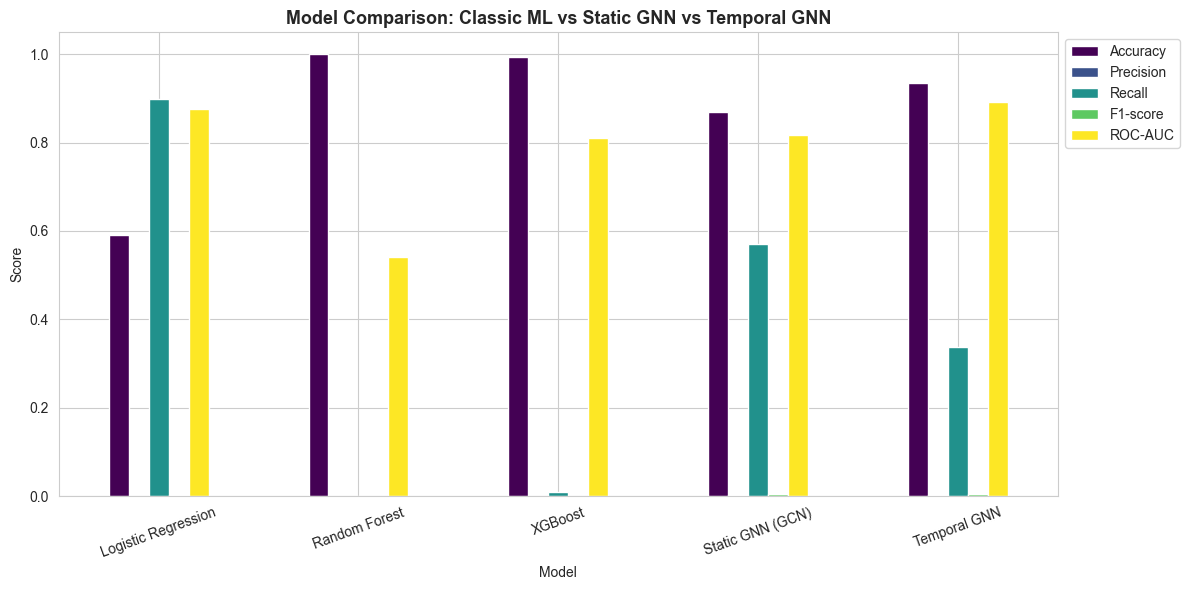

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Model Comparison: Classic ML vs Static GNN vs Temporal GNN")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Reading the grouped bar chart.** The figure places all five metrics side by side for each model,
which makes the accuracy inversion immediately visible: the tallest accuracy bars belong to the
models that catch the least.

One caution on this chart type for the write-up. Plotting accuracy, precision, recall, F1 and
ROC-AUC on a single 0-to-1 axis implies they are comparable quantities, and in this problem they
are not: accuracy is meaningless, precision is compressed against zero for every model, and F1
inherits that compression. A reader scanning quickly could take the random forest's tall accuracy
bar as a strong result. If the figure is reproduced in the dissertation it is worth either
dropping accuracy from it or annotating it directly, so the chart cannot be misread in isolation.


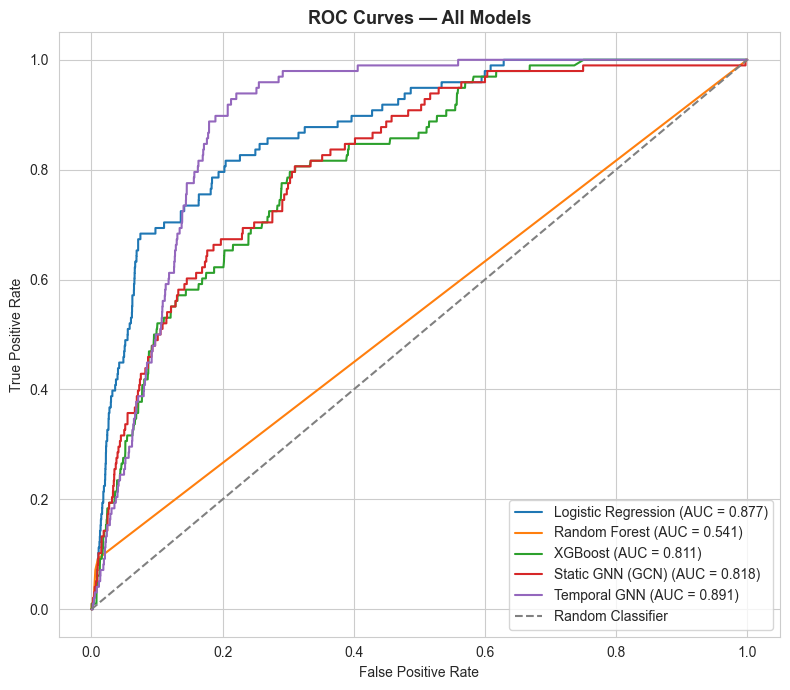

In [45]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr) in roc_data.items():
    auc_score = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Reading the ROC curves.** All five models appear on shared axes against the diagonal random
baseline, which is the cleanest single figure for the comparison because it is threshold-free. The
temporal GNN's curve sits highest over most of the range, the random forest tracks the diagonal
almost exactly, confirming that its AUC of 0.541 reflects near-random ordering, and the remaining
three are clustered between.

**The region that matters is the far left.** In deployment the operating point is at a very low
false-positive rate, because that is where alert volume is affordable, so the useful comparison is
the height of each curve in roughly the first 1 to 5 per cent of the x-axis rather than the total
area beneath it. Two models with similar AUC can behave very differently there.

**The caveat to carry into the discussion.** Under 3,435-to-1 imbalance the ROC curve flatters
every model, because the false-positive rate has 209,509 negatives in its denominator: the
temporal GNN's 13,548 false positives correspond to an FPR of only 0.065, which looks modest on
this axis and is 13,548 investigations in practice. **A precision-recall curve would not flatter
in this way**, since precision is computed against the alerts actually raised. Adding one is the
single most valuable addition to this figure set and is repeated in Section 13.3.


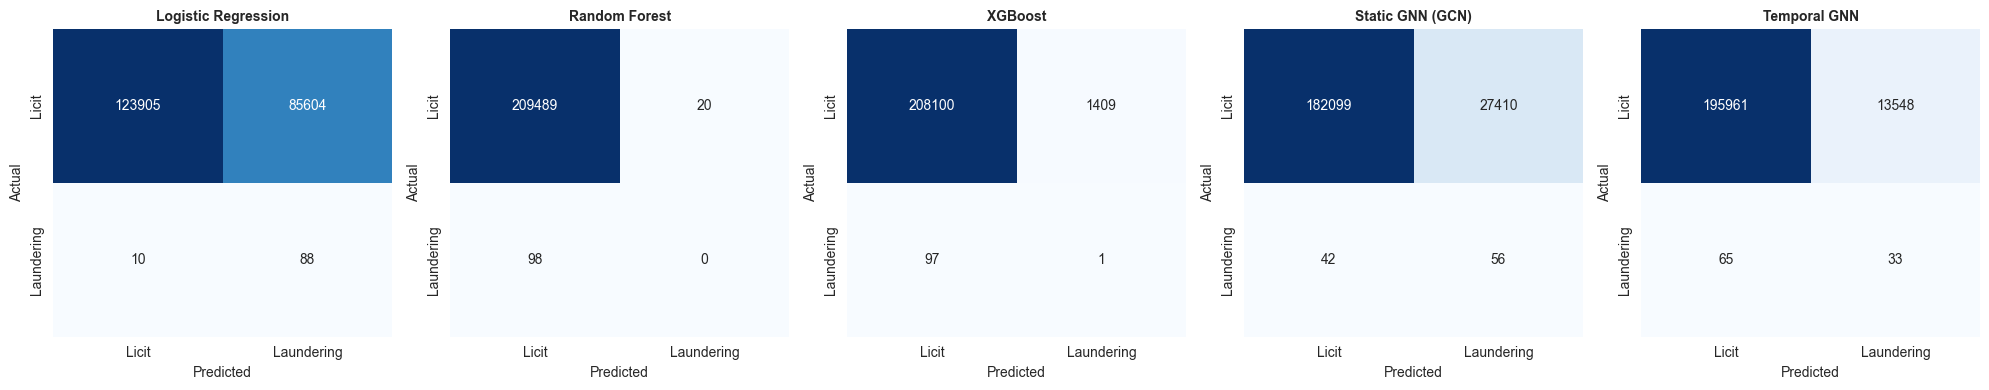

In [47]:
# Confusion matrices side-by-side, focusing on false positives (a key concern per Objective 5)
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
if len(results) == 1:
    axes = [axes]

model_preds = {
    "Logistic Regression": lr.predict(Xte_scaled),
    "Random Forest": rf.predict(Xte),
    "XGBoost": xgb_clf.predict(Xte),
}
# Static GNN & Temporal GNN predictions were computed above as `preds` and `all_preds` respectively;
# re-derive them here explicitly to keep this cell self-contained if run independently.
model_preds["Static GNN (GCN)"] = preds
model_preds["Temporal GNN"] = all_preds

model_true = {
    "Logistic Regression": yte, "Random Forest": yte, "XGBoost": yte,
    "Static GNN (GCN)": yte.values, "Temporal GNN": np.array(all_true)
}

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(model_true[name], model_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Licit', 'Laundering'], yticklabels=['Licit', 'Laundering'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 12.3 The false-positive burden

**Reading the confusion matrices.** These panels make the alert burden concrete in a way the rate
metrics conceal, which is exactly what Objective 5 requires.

| Model | True positives | False negatives | False positives | Investigator burden |
|---|---:|---:|---:|---|
| Logistic Regression | 88 | 10 | 85,604 | Not viable at any staffing level |
| Static GNN | 56 | 42 | 27,410 | Not viable |
| Temporal GNN | 33 | 65 | 13,548 | Not viable, but an order of magnitude better than LR |
| XGBoost | 1 | 97 | 1,409 | Low burden, no detection value |
| Random Forest | 0 | 98 | 20 | No detection at all |

Put in operational terms: the test period is 7.5 hours. A team clearing 13,548 alerts in that
window would need to close roughly 30 cases per minute. Even the lightest-burden model that
catches anything, XGBoost at 1,410 alerts, catches one laundering transaction for its trouble.

**The correct interpretation is that these matrices reflect the 0.5 threshold, not the ceiling of
the models.** A ROC-AUC of 0.891 means the temporal GNN's ranking is genuinely informative; the
0.5 cut-off is simply the wrong place to slice it. The models were also trained with class weights
of several thousand to one, which by construction pushes predicted probabilities upward and makes
0.5 a very aggressive cut-off. Section 13.3 sets out the threshold selection procedure that
converts this ranking quality into a workable operating point, and that procedure is the main
piece of unfinished work in the evaluation.


## 13. Conclusions, Limitations and Further Work

### 13.1 Findings against the objectives

**Objective 1, classic ML baselines.** Established and, importantly, shown to fail in
characteristic ways. Logistic regression achieves high recall (88 of 98) at an alert rate of 40.9
per cent. The random forest collapses to the majority class (AUC 0.541). XGBoost ranks acceptably
(AUC 0.811) but converts that into a single detection at the default threshold. The general
conclusion is that transaction-at-a-time tabular modelling is inadequate to this problem, which is
consistent with the box plot in Section 4 showing that laundering amounts are not separable from
licit ones.

**Objective 2, graph construction.** A directed transaction graph over 423,310 accounts and
1,048,033 edges, with degree and value features per node, built from the training period only to
prevent structural leakage.

**Objective 3, temporal architecture.** A snapshot GCN with GRU memory implemented and trained.
The architecture is sound and it produced the best ROC-AUC in the study at 0.891. The temporal
component itself remains untested because the sample resolves to a single snapshot, and this is
stated as a limitation rather than glossed.

**Objective 4, comparative evaluation.** Completed under a shared protocol. Graph models rank
above tabular models: 0.891 and 0.818 against 0.811 and 0.541, with logistic regression an outlier
at 0.877 achieved through indiscriminate flagging.

**Objective 5, false-positive burden.** Quantified. Alert rates run from 0.7 per cent to 40.9 per
cent of all transactions, and no model is deployable at a 0.5 threshold. The temporal GNN offers
the best burden-to-detection trade-off among the models that detect anything.

### 13.2 Limitations

**A single day of data.** The 5 per cent day-based sample resolves to one calendar day. This
suppresses the temporal mechanism, prevents any day-of-week or multi-day typology from appearing,
and forces the train/test split inside a single day, which in turn makes the hour feature nearly
useless because the two periods occupy disjoint hour ranges.

**Only 98 test positives.** Every recall figure has 98 as its denominator, and the confidence
intervals in Section 12.2 are correspondingly wide. Differences below roughly 10 percentage points
of recall are not resolvable at this sample size.

**Synthetic data.** The IBM generator provides complete ground truth, without which recall could
not be measured, but its typologies are those its authors implemented. Performance here is not
evidence of performance on real payment flows.

**Default threshold throughout.** All binary metrics use 0.5, chosen by default rather than
selected. This is the primary reason the precision figures look as they do and it is correctable
without retraining.

**Label encoding of categorical features.** Currency and format are integer-encoded, which imposes
a false ordinal relationship on the linear and neural models. One-hot encoding or learned
embeddings would be correct.

**Encoders fitted before the split.** A mild leakage of test-period category vocabulary, with
negligible practical impact here since the category set is closed, but it should be corrected.

**No validation split or early stopping.** Epoch budgets of 30 and 15 were fixed arbitrarily. The
GCN loss was still falling at epoch 30, so the static GNN result is probably a lower bound.

**Transductive setting.** The node vocabulary spans the whole sample, so accounts appearing only
in the test period carry uninformative features. Detection of newly created mule accounts is
therefore outside what this implementation can demonstrate.

**Two duplicate rows retained.** Negligible in effect, trivial to fix, and worth fixing since
duplicated edges perturb the degree features.

### 13.3 Recommendations for the final run

In descending order of value.

**1. Raise SAMPLE_FRAC to obtain multiple days.** This is the single highest-value change. It
gives the GRU a real sequence, increases the positive count and therefore the statistical power,
and moves the train/test boundary between days so the hour feature becomes usable. If memory
becomes the constraint, switch the snapshot loop to hourly bins first as an interim measure.

**2. Select the decision threshold rather than accepting 0.5.** Hold out the last portion of the
training period as a validation set, compute the precision-recall curve, and choose the operating
point from an alert budget (for example, the top 500 transactions per day, matching realistic
analyst capacity). Report precision-at-k and recall-at-k alongside the current metrics. This
alone will transform the precision column, particularly for XGBoost.

**3. Add average precision to the evaluation function.** One line, and it is the metric the
imbalanced-learning literature considers correct for this setting. Add a precision-recall curve
figure beside the ROC figure.

**4. Fix the random forest configuration.** Use class_weight="balanced_subsample", constrain
max_depth and min_samples_leaf, or use balanced bagging. The current result is reportable as a
finding, but a properly configured forest is the fairer baseline.

**5. Add a validation split with early stopping** for both neural models, and report the epoch at
which each was stopped.

**6. Correct the encoding issues.** One-hot encode currency and format, or add embedding layers to
the GNNs, and fit the encoders after the chronological split.

### 13.4 Further work

**Architectural.** Graph attention (GAT) would let the model weight neighbours rather than
averaging them, which directly addresses the hub-smoothing problem identified in the EDA.
GraphSAGE with neighbour sampling would make the approach inductive, handling accounts unseen at
training time, and would remove the full-batch memory ceiling. A continuous-time model such as TGN
would avoid snapshot binning altogether.

**Feature-level.** Motif counts for the specific structures that define laundering typologies,
fan-in, fan-out and cycles of length 3 and 4, would give the model explicit access to patterns it
currently has to infer. Velocity features over rolling windows would capture the rapid
receive-and-disperse signature that a static graph cannot express.

**Evaluation.** Cost-sensitive evaluation, assigning a monetary cost to a missed laundering case
and an analyst-hour cost to a false positive, would replace the arbitrary threshold with an
economically grounded operating point and would let the models be ranked on the quantity a
compliance function actually cares about.

**Validation.** Repeat the comparison on the LI (lower illicit ratio) variant of the benchmark and
on a second dataset such as the Elliptic bitcoin graph, to establish whether the ranking of model
families holds beyond a single generator.
